In [1]:
# Notebook setup
%load_ext autoreload
%autoreload 2
import os
import sys
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

In [2]:
from cerebra_atlas_python import CerebrA

cerebra = CerebrA()

<class 'numpy.ndarray'> True


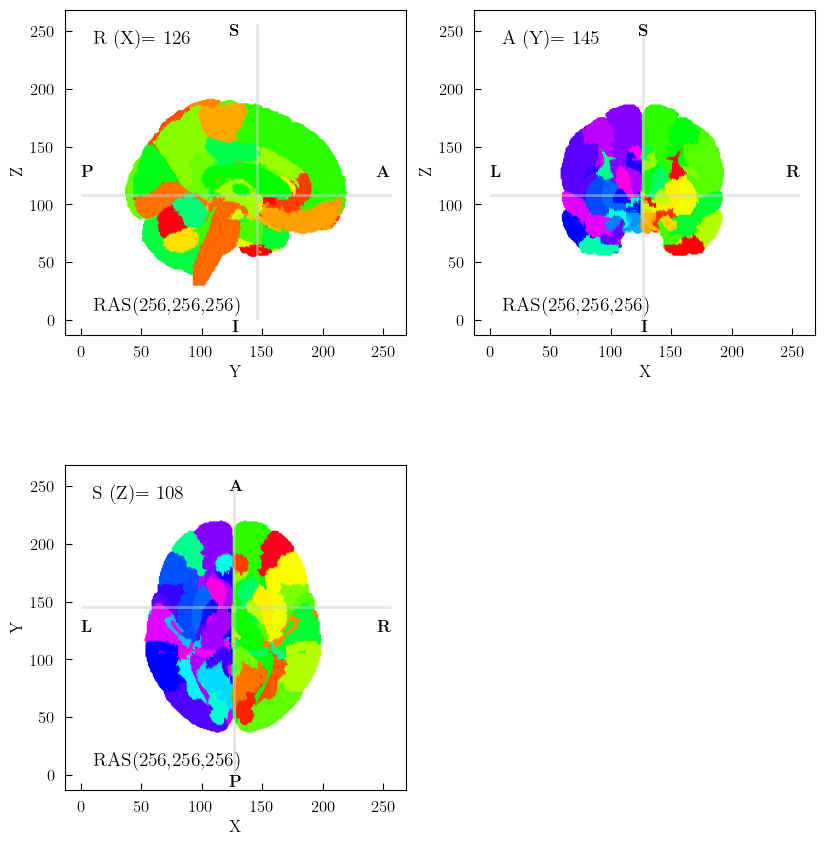

In [31]:
import matplotlib.pyplot as plt

cerebra.plot_2d(ax_label_text_size=12, plot_affine=True, kind="orthoview", figsize=(10, 10),plot_coordinate_frame_info=True,plot_narrow_ax=False)
plt.savefig("cerebra_orthoview.png", dpi=300, bbox_inches='tight')

In [3]:
cerebra_img = cerebra.cerebra_img.get_fdata()
wm_img = cerebra.wm_img.get_fdata()

In [4]:
1169569 * 100 / (256 * 256 * 256)

6.971174478530884

In [5]:
((cerebra.cerebra_volume != 0) & (cerebra.cerebra_volume != 103)).sum()

1169569

In [6]:
for region_id in range(1, 103):
    cerebra._label_details.loc[region_id, "density"] = (
        cerebra.cerebra_volume == region_id
    ).sum()

In [7]:
cerebra._label_details["density_rel"] = (
    cerebra._label_details["density"] / cerebra._label_details["density"].sum()
) * 100
cerebra._label_details

,Mindboggle ID,Label Name,CerebrA ID,hemisphere,cortical,color,density,density_rel
0,0.0,Empty,0,NaN,NaN,#000000,NaN,NaN
1,2027.0,Rostral Middle Frontal,1,Right,True,#ff001e,21742.0,1.858975
2,631.0,Vermal lobules VI-VII,2,Right,False,#ff0013,2324.0,0.198706
3,2009.0,Inferior temporal,3,Right,True,#ff0003,16224.0,1.387178
4,58.0,Accumbens Area,4,Right,False,#ff0700,553.0,0.047282
...,...,...,...,...,...,...,...,...
99,53.0,Hippocampus,99,Left,False,#ff00f0,4694.0,0.401344
100,50.0,Caudate,100,Left,False,#ff00e5,5643.0,0.482485
101,630.0,Vermal lobules I-V,101,Left,False,#ff00d4,3963.0,0.338843
102,1031.0,Supramarginal,102,Left,True,#ff00ca,16033.0,1.370847


In [8]:
colors = cerebra._label_details.iloc[1:103]["color"].to_numpy()
for i, c in enumerate(colors):
    print("\definecolor{cerebraColor" + str(i + 1) + "}{HTML}{" + c[1:] + "}")

\definecolor{cerebraColor1}{HTML}{ff001e}
\definecolor{cerebraColor2}{HTML}{ff0013}
\definecolor{cerebraColor3}{HTML}{ff0003}
\definecolor{cerebraColor4}{HTML}{ff0700}
\definecolor{cerebraColor5}{HTML}{ff1700}
\definecolor{cerebraColor6}{HTML}{ff2200}
\definecolor{cerebraColor7}{HTML}{ff3200}
\definecolor{cerebraColor8}{HTML}{ff3d00}
\definecolor{cerebraColor9}{HTML}{ff4d00}
\definecolor{cerebraColor10}{HTML}{ff5800}
\definecolor{cerebraColor11}{HTML}{ff6800}
\definecolor{cerebraColor12}{HTML}{ff7300}
\definecolor{cerebraColor13}{HTML}{ff8300}
\definecolor{cerebraColor14}{HTML}{ff8e00}
\definecolor{cerebraColor15}{HTML}{ff9e00}
\definecolor{cerebraColor16}{HTML}{ffa900}
\definecolor{cerebraColor17}{HTML}{ffb900}
\definecolor{cerebraColor18}{HTML}{ffc400}
\definecolor{cerebraColor19}{HTML}{ffd400}
\definecolor{cerebraColor20}{HTML}{ffdf00}
\definecolor{cerebraColor21}{HTML}{ffef00}
\definecolor{cerebraColor22}{HTML}{fffa00}
\definecolor{cerebraColor23}{HTML}{f3ff00}
\definecolor{cerebra

In [9]:
df = cerebra._label_details[
    (cerebra._label_details["cortical"] == False)
    & (cerebra._label_details["hemisphere"] == "Right")
]
df["Mindboggle ID"] = df["Mindboggle ID"].astype(int)
df = (
    df[["CerebrA ID", "Mindboggle ID", "Label Name", "color", "density_rel"]]
    .reset_index(drop=True)
    .rename(
        columns={"Label Name": "Name", "color": "Color", "density_rel": "Density (%)"}
    )
)

/tmp/ipykernel_36936/3272903371.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Mindboggle ID"] = df["Mindboggle ID"].astype(int)


In [10]:
df["Color"] = df["CerebrA ID"].apply(lambda x: "cerebraColor" + str(x))
df["Density (%)"] = df["Density (%)"].apply(lambda x: f"{x:.2f}")
# df["Color"] = df["Color"].apply(lambda x: "\\fcolorbox{black}{"+x+"}{\rule{0pt}{6pt}\rule{6pt}{0pt}}\quad")

In [11]:
df

,CerebrA ID,Mindboggle ID,Name,Color,Density (%)
0,2,631,Vermal lobules VI-VII,cerebraColor2,0.20
1,4,58,Accumbens Area,cerebraColor4,0.05
2,5,44,Inferior Lateral Ventricle,cerebraColor5,0.09
3,11,16,Brainstem,cerebraColor11,1.45
4,17,85,Optic Chiasm,cerebraColor17,0.07
5,19,54,Amygdala,cerebraColor19,0.14
6,20,632,Vermal lobules VIII-X,cerebraColor20,0.22
7,21,51,Putamen,cerebraColor21,0.57
8,25,92,Basal Forebrain,cerebraColor25,0.02
9,26,60,Ventral Diencephalon,cerebraColor26,0.52


In [12]:
print(df.to_latex(index=False))

\begin{tabular}{rrlll}
\toprule
CerebrA ID & Mindboggle ID & Name & Color & Density (%) \\
\midrule
2 & 631 & Vermal lobules VI-VII & cerebraColor2 & 0.20 \\
4 & 58 & Accumbens Area & cerebraColor4 & 0.05 \\
5 & 44 & Inferior Lateral Ventricle & cerebraColor5 & 0.09 \\
11 & 16 & Brainstem & cerebraColor11 & 1.45 \\
17 & 85 & Optic Chiasm & cerebraColor17 & 0.07 \\
19 & 54 & Amygdala & cerebraColor19 & 0.14 \\
20 & 632 & Vermal lobules VIII-X & cerebraColor20 & 0.22 \\
21 & 51 & Putamen & cerebraColor21 & 0.57 \\
25 & 92 & Basal Forebrain & cerebraColor25 & 0.02 \\
26 & 60 & Ventral Diencephalon & cerebraColor26 & 0.52 \\
27 & 52 & Pallidum & cerebraColor27 & 0.15 \\
29 & 14 & Third Ventricle & cerebraColor29 & 0.09 \\
37 & 15 & Fourth Ventricle & cerebraColor37 & 0.07 \\
39 & 46 & Cerebellum White Matter & cerebraColor39 & 1.11 \\
40 & 49 & Thalamus & cerebraColor40 & 0.86 \\
41 & 43 & Lateral Ventricle & cerebraColor41 & 0.82 \\
46 & 45 & Cerebellum Gray Matter & cerebraColor46 & 6.09